# Data merge and feature engineering


## I. Importing essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path
import json

import folium
from folium.plugins import TimeSliderChoropleth
import requests
import branca.colormap as cm
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

## II. Importing datasets and creating base dataframes

In [2]:
data_dir = Path("../data")
weather_file = data_dir / "final_weather.csv"
alarms_file = data_dir / "war_events_processed.csv"
isw_file = data_dir / "isw_processed_svd.csv"
tg_file = data_dir / "telegram_processed_svd.csv"
tg_region = data_dir / "tg_region_features.csv"

output = "../data/final_merged_dataset.parquet"

In [3]:
df_weather = pd.read_csv(weather_file)
df_war_events = pd.read_csv(alarms_file)
df_isw_matrix = pd.read_csv(isw_file)
df_tg_matrix = pd.read_csv(tg_file)
df_tg_region = pd.read_csv(tg_region)

## III. Data merge

### Weather (main) and War_events merge

In [4]:
df_weather.shape

(853536, 39)

In [5]:
df_war_events.shape

(924664, 5)

In [6]:
df_weather.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,hour,day_datetime,day_sunrise,day_sunset,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,region_key,region_id
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0,2022-02-24,06:58:49,17:40:52,False,True,False,False,Вінницька,2
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,1,2022-02-24,06:58:49,17:40:52,False,True,False,False,Вінницька,2
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,2,2022-02-24,06:58:49,17:40:52,False,True,False,False,Вінницька,2
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,3,2022-02-24,06:58:49,17:40:52,False,True,False,False,Вінницька,2
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,4,2022-02-24,06:58:49,17:40:52,False,True,False,False,Вінницька,2


In [7]:
df_war_events.head()

,datetime_hour,region_id,region_key,alarm_minutes_in_hour,alarm_active
0,2022-02-24 00:00:00,1,АР Крим,0.0,0
1,2022-02-24 00:00:00,2,Вінницька,0.0,0
2,2022-02-24 00:00:00,3,Волинська,0.0,0
3,2022-02-24 00:00:00,4,Дніпропетровська,0.0,0
4,2022-02-24 00:00:00,5,Донецька,0.0,0


In [8]:
df_weather['datetime_hour'] = pd.to_datetime(df_weather['datetime_hour'], errors="coerce")
df_war_events['datetime_hour'] = pd.to_datetime(df_war_events['datetime_hour'], errors="coerce")

In [9]:
df_final = pd.merge(df_weather, df_war_events[['datetime_hour', 'region_id', 'alarm_active', 'alarm_minutes_in_hour']], on=['datetime_hour', 'region_id'], how='left')

In [10]:
df_final.shape

(853536, 41)

In [11]:
print(f"Main dataset rows before merge: {df_weather.shape[0]} \nMain datased rows after merge: {df_final.shape[0]} \n{'Merge correct' if df_weather.shape[0]==df_final.shape[0] else 'Merge incorrect'}")

Main dataset rows before merge: 853536 
Main datased rows after merge: 853536 
Merge correct


In [12]:
df_final['region_key'].unique()

array(['Вінницька', 'Волинська', 'Дніпропетровська', 'Донецька',
       'Житомирська', 'Закарпатська', 'Запорізька', 'Івано-Франківська',
       'Київська', 'Кіровоградська', 'Львівська', 'Миколаївська',
       'Одеська', 'Полтавська', 'Рівненська', 'Сумська', 'Тернопільська',
       'Харківська', 'Херсонська', 'Хмельницька', 'Черкаська',
       'Чернівецька', 'Чернігівська', 'Київ'], dtype=object)

#### We have 817972 rows, just as in main weather dataset, due to the lack of data on occupied territory - Crimea and Luhansk. 

In [13]:
df_final = df_final.sort_values(['region_id', 'datetime_hour'])
df_final.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,day_sunrise,day_sunset,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,region_key,region_id,alarm_active,alarm_minutes_in_hour
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0


In [14]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853536 entries, 0 to 853535
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   city_name                      853536 non-null  object        
 1   datetime_hour                  853536 non-null  datetime64[ns]
 2   day_tempmax                    853536 non-null  float64       
 3   day_tempmin                    853536 non-null  float64       
 4   day_temp                       853536 non-null  float64       
 5   day_dew                        853536 non-null  float64       
 6   day_humidity                   853536 non-null  float64       
 7   day_precip                     853536 non-null  float64       
 8   day_precipcover                853536 non-null  float64       
 9   day_snow                       853536 non-null  float64       
 10  day_windgust                   853536 non-null  float64       
 11  

### ISW Merge

In [15]:
df_isw_matrix.shape

(1469, 151)

In [16]:
df_isw_matrix.head()

,date,isw_topic_0,isw_topic_1,isw_topic_2,isw_topic_3,isw_topic_4,isw_topic_5,isw_topic_6,isw_topic_7,isw_topic_8,...,isw_topic_140,isw_topic_141,isw_topic_142,isw_topic_143,isw_topic_144,isw_topic_145,isw_topic_146,isw_topic_147,isw_topic_148,isw_topic_149
0,2022-02-24,0.287951,0.141218,0.095502,0.107672,-0.074906,0.118477,0.261878,0.049509,-0.147448,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.016180,0.028906,0.022299,-0.007891,-0.045698,-0.049911
1,2022-02-25,0.200608,0.110314,0.173969,0.166369,-0.040344,0.259030,0.174063,0.146297,-0.287907,...,-0.015106,-0.007861,0.031419,0.054214,-0.016449,0.011678,-0.018715,-0.031704,-0.024248,-0.036044
2,2022-02-26,0.206834,0.130746,0.228587,0.209877,-0.044341,0.310827,0.217224,0.167180,-0.315905,...,-0.011074,0.007637,0.067367,0.041350,-0.011430,-0.004380,-0.010025,0.004530,-0.025416,-0.035281
3,2022-02-27,0.227203,0.136781,0.221685,0.207126,-0.052803,0.295562,0.192686,0.156390,-0.293632,...,-0.008148,0.020819,0.062540,-0.000088,-0.005445,0.002048,0.015895,-0.005384,-0.009167,-0.029646
4,2022-02-28,0.231658,0.130188,0.236681,0.206732,-0.051758,0.299442,0.203047,0.145515,-0.230570,...,0.022454,-0.029293,0.024632,-0.091568,-0.028723,-0.012257,0.004621,0.031608,0.018031,-0.023155


In [17]:
df_final.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,day_sunrise,day_sunset,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,region_key,region_id,alarm_active,alarm_minutes_in_hour
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,06:58:49,17:40:52,False,True,False,False,Вінницька,2,0,0.0


In [18]:
df_isw_matrix = df_isw_matrix.rename(columns={'date': 'day_datetime'})

In [19]:
df_final['day_datetime'] = pd.to_datetime(df_final['day_datetime']).dt.date
df_isw_matrix['day_datetime'] = pd.to_datetime(df_isw_matrix['day_datetime']).dt.date

In [20]:
df_isw_matrix.isna().sum()

day_datetime     0
isw_topic_0      0
isw_topic_1      0
isw_topic_2      0
isw_topic_3      0
                ..
isw_topic_145    0
isw_topic_146    0
isw_topic_147    0
isw_topic_148    0
isw_topic_149    0
Length: 151, dtype: int64

In [21]:
df_isw_matrix = df_isw_matrix.fillna(0)

In [22]:
rows_before = df_final.shape[0]

In [23]:
df_final = df_final.merge(df_isw_matrix, on="day_datetime", how="left")

In [24]:
rows_after = df_final.shape[0]

In [25]:
print(f"Before: {rows_before} rows.\nAfter: {rows_after} rows.\n{'Merge correct' if rows_before == rows_after else 'Merge incorrect'}")

Before: 853536 rows.
After: 853536 rows.
Merge correct


In [26]:
df_final.head(15)

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_140,isw_topic_141,isw_topic_142,isw_topic_143,isw_topic_144,isw_topic_145,isw_topic_146,isw_topic_147,isw_topic_148,isw_topic_149
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
5,Vinnytsia,2022-02-24 05:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
6,Vinnytsia,2022-02-24 06:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
7,Vinnytsia,2022-02-24 07:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
8,Vinnytsia,2022-02-24 08:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911
9,Vinnytsia,2022-02-24 09:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,-0.030101,-0.021112,-0.018383,-0.005687,-0.01618,0.028906,0.022299,-0.007891,-0.045698,-0.049911


In [27]:
df_final.shape

(853536, 191)

In [28]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853536 entries, 0 to 853535
Columns: 191 entries, city_name to isw_topic_149
dtypes: bool(4), datetime64[ns](1), float64(177), int64(4), object(5)
memory usage: 1.2+ GB


### Telegram Merge

In [29]:
df_tg_matrix.shape

(130418, 252)

In [30]:
df_tg_matrix.head()

,date,channel,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,2026-03-17 01:31:21,kpszsu,0.001725,0.000921,-0.002349,0.001275,0.034959,0.000286,0.000650,-0.004697,...,0.020521,0.000225,-0.009665,0.032675,0.028853,0.050622,-0.015936,0.002112,-0.005634,-0.007368
1,2026-03-17 01:21:32,kpszsu,0.001465,0.000690,-0.001656,0.001211,0.024250,0.004542,0.000249,-0.002528,...,0.059172,-0.022509,-0.010354,0.020303,0.053664,-0.002435,-0.017253,0.024965,0.053843,0.008204
2,2026-03-17 00:45:16,kpszsu,0.002459,0.000994,-0.002841,0.001615,0.041195,0.004027,0.000464,-0.005420,...,-0.041444,0.000833,-0.006495,-0.021271,-0.017965,0.032298,0.001182,-0.027834,-0.049556,-0.007368
3,2026-03-17 00:33:10,kpszsu,0.001685,0.000910,-0.001983,0.001282,0.026910,0.002017,0.000571,-0.002888,...,0.005464,-0.008645,0.000925,0.000010,-0.008634,-0.013411,0.011467,0.002963,0.003629,0.015706
4,2026-03-16 23:30:39,kpszsu,0.000636,0.000214,-0.000975,0.000328,0.016909,-0.001615,0.000386,-0.003499,...,-0.020132,0.011241,0.033127,-0.004255,-0.017979,0.005180,-0.028860,0.007619,0.000275,0.006776


In [31]:
df_tg_matrix.tail(5)

,date,channel,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
130413,2022-02-25 09:45:10,kpszsu,0.000175,5.303045e-07,-0.000123,0.000132,0.000924,0.003554,-0.000197,-0.000660,...,0.001467,0.000081,0.001082,-0.003481,-0.001322,0.005306,0.001585,0.001711,-0.001273,-0.000517
130414,2022-02-25 09:43:53,kpszsu,0.001040,1.686524e-04,-0.000855,0.001182,0.006341,0.013680,-0.001307,0.000201,...,-0.006615,0.001020,-0.001902,0.004741,0.006081,0.005248,-0.003163,0.004947,0.009791,0.002779
130415,2022-02-25 00:43:47,kpszsu,0.000880,2.404102e-04,-0.000892,0.001272,0.007347,0.015354,-0.001517,-0.000531,...,0.001759,0.000131,0.013777,-0.001525,0.003588,-0.005376,-0.006769,-0.007399,0.027291,0.002060
130416,2022-02-25 00:43:23,kpszsu,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
130417,2022-02-24 23:17:22,kpszsu,0.000157,4.229660e-05,-0.000175,0.000391,0.002821,0.008953,-0.000879,-0.001318,...,-0.020102,0.014899,-0.002224,-0.029557,0.014319,0.000838,-0.019300,0.001061,-0.017080,-0.000862


In [32]:
df_tg_matrix['datetime_hour'] = pd.to_datetime(df_tg_matrix['date']).dt.floor('h')

In [33]:
topic_cols = [c for c in df_tg_matrix.columns if 'tg_topic_' in c]
tg_hourly = (df_tg_matrix.groupby('datetime_hour')[topic_cols].mean().sort_index().reset_index())

In [34]:
tg_hourly.head()

,datetime_hour,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,tg_topic_8,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,2022-02-24 05:00:00,0.000077,0.000045,-0.000178,0.000252,0.001791,0.007414,-0.000725,-0.001075,0.000703,...,0.008024,-0.007064,0.001437,-0.014404,0.013012,0.000976,-0.010546,-0.021099,-0.003620,-0.010649
1,2022-02-24 06:00:00,0.000249,-0.000055,-0.000058,0.000015,0.000668,0.002395,-0.000236,-0.000387,0.000365,...,-0.001706,0.000273,0.004814,-0.003213,-0.002459,-0.001242,0.001075,-0.001673,-0.000124,0.000024
2,2022-02-24 07:00:00,0.000016,0.000006,-0.000030,0.000034,0.000220,0.000592,-0.000053,0.000023,0.000233,...,-0.008132,-0.015778,-0.013207,-0.005428,0.000068,0.008652,0.006404,-0.018893,0.012722,0.024673
3,2022-02-24 08:00:00,0.001002,0.000907,-0.001224,0.000854,0.009855,0.006149,-0.000238,0.006604,0.002009,...,-0.000876,0.001540,0.001673,0.003509,-0.010160,0.001350,-0.004811,-0.008902,0.004540,0.004997
4,2022-02-24 09:00:00,0.000604,0.000385,-0.000524,0.000396,0.004478,0.006186,-0.000529,0.001633,0.003588,...,-0.009617,-0.000423,-0.006073,-0.005574,-0.008614,0.005244,0.012026,-0.006452,-0.000387,0.001368


In [35]:
all_hours = pd.DataFrame({'datetime_hour': pd.date_range(df_final['datetime_hour'].min(), df_final['datetime_hour'].max(), freq='h')})
tg_hourly = all_hours.merge(tg_hourly, on='datetime_hour', how='left').fillna(0)

In [36]:
tg_hourly.head(10)

,datetime_hour,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,tg_topic_8,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,2022-02-24 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2022-02-24 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2022-02-24 02:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2022-02-24 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2022-02-24 04:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,2022-02-24 05:00:00,0.000077,0.000045,-0.000178,0.000252,0.001791,0.007414,-0.000725,-0.001075,0.000703,...,0.008024,-0.007064,0.001437,-0.014404,0.013012,0.000976,-0.010546,-0.021099,-0.003620,-0.010649
6,2022-02-24 06:00:00,0.000249,-0.000055,-0.000058,0.000015,0.000668,0.002395,-0.000236,-0.000387,0.000365,...,-0.001706,0.000273,0.004814,-0.003213,-0.002459,-0.001242,0.001075,-0.001673,-0.000124,0.000024
7,2022-02-24 07:00:00,0.000016,0.000006,-0.000030,0.000034,0.000220,0.000592,-0.000053,0.000023,0.000233,...,-0.008132,-0.015778,-0.013207,-0.005428,0.000068,0.008652,0.006404,-0.018893,0.012722,0.024673
8,2022-02-24 08:00:00,0.001002,0.000907,-0.001224,0.000854,0.009855,0.006149,-0.000238,0.006604,0.002009,...,-0.000876,0.001540,0.001673,0.003509,-0.010160,0.001350,-0.004811,-0.008902,0.004540,0.004997
9,2022-02-24 09:00:00,0.000604,0.000385,-0.000524,0.000396,0.004478,0.006186,-0.000529,0.001633,0.003588,...,-0.009617,-0.000423,-0.006073,-0.005574,-0.008614,0.005244,0.012026,-0.006452,-0.000387,0.001368


In [37]:
rows_before = df_final.shape[0]

In [38]:
df_final = df_final.merge(tg_hourly, on="datetime_hour", how="left")

In [39]:
rows_after = df_final.shape[0]

In [40]:
df_final.shape

(853536, 441)

In [41]:
print(f"Before: {rows_before} rows.\nAfter: {rows_after} rows.\n{'Merge correct' if rows_before == rows_after else 'Merge incorrect'}")

Before: 853536 rows.
After: 853536 rows.
Merge correct


In [42]:
df_final.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
df_final.tail()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
853531,Kyiv,2026-03-16 19:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,-0.001226,-0.003287,0.004531,0.008950,-0.004226,0.020651,-0.018043,0.003978,-0.015883,-0.006269
853532,Kyiv,2026-03-16 20:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.030740,0.002578,0.014086,-0.021863,-0.062492,0.032188,-0.017823,0.035902,-0.017004,-0.046561
853533,Kyiv,2026-03-16 21:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.011017,0.017095,0.002764,0.005640,0.009055,0.004993,0.022719,0.005768,0.011629,-0.005454
853534,Kyiv,2026-03-16 22:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.035442,0.068392,0.001231,0.030280,0.000135,-0.000753,0.052926,0.002041,-0.015368,-0.045442
853535,Kyiv,2026-03-16 23:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.008623,0.033626,0.018985,-0.000511,0.004026,0.008591,0.010192,0.010548,0.009417,-0.019262


In [44]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853536 entries, 0 to 853535
Columns: 441 entries, city_name to tg_topic_249
dtypes: bool(4), datetime64[ns](1), float64(427), int64(4), object(5)
memory usage: 2.8+ GB


### tg_region_features.csv Merge

In [45]:
df_tg_region["datetime_hour"] = pd.to_datetime(df_tg_region["datetime_hour"])
df_tg_region["region_id"] = pd.to_numeric(df_tg_region["region_id"], errors="coerce")
df_final["region_id"] = pd.to_numeric(df_final["region_id"], errors="coerce")

In [46]:
tg_region_cols = [
    "tg_region_threat_count",
    "tg_region_allclear_count",
    "tg_region_mention_count",
]

for col in tg_region_cols:
    df_tg_region[col] = pd.to_numeric(df_tg_region[col], errors="coerce").fillna(0)

In [47]:
df_final = df_final.merge(
    df_tg_region[["datetime_hour", "region_id", *tg_region_cols]],
    on=["datetime_hour", "region_id"],
    how="left",
)

df_final[tg_region_cols] = df_final[tg_region_cols].fillna(0)

In [48]:
print(df_final.shape)

(853536, 444)


## IV. Feature engineering

### Alarms & weather

In [49]:
df_final = df_final.sort_values(['region_id', 'datetime_hour'])

In [50]:
df_final['alarm_lag_1'] = df_final.groupby('region_id')['alarm_active'].shift(1)
df_final['alarm_lag_3'] = df_final.groupby('region_id')['alarm_active'].shift(3)
df_final['alarm_lag_6'] = df_final.groupby('region_id')['alarm_active'].shift(6)
df_final['alarm_lag_12'] = df_final.groupby('region_id')['alarm_active'].shift(12)

lag_cols = ['alarm_lag_1', 'alarm_lag_3', 'alarm_lag_6', 'alarm_lag_12']
df_final[lag_cols] = df_final[lag_cols].fillna(0)

In [51]:
df_final['alarms_in_last_24h'] = df_final.groupby('region_id')['alarm_active'].transform(lambda x: x.shift(1).rolling(24, min_periods=1).sum())
df_final['alarms_in_last_24h'] = df_final['alarms_in_last_24h'].fillna(0)

In [52]:
df_final['is_weekend'] = df_final['day_of_week'].isin([5, 6]).astype(int)
df_final['is_night'] = ((df_final['hour'] >= 23) | (df_final['hour'] <= 6)).astype(int)

In [53]:
hourly_total = df_final.groupby('datetime_hour')['alarm_active'].sum().shift(1)
df_final['total_active_alarms_lag1'] = df_final['datetime_hour'].map(hourly_total)
df_final['total_active_alarms_lag1'] = df_final['total_active_alarms_lag1'].fillna(0)

In [54]:
neighbouring_regions = {
    1: [21],
    2: [6, 10, 11, 15, 22, 23, 24],
    3: [13, 17],
    4: [5, 8, 11, 14, 16, 20, 21],
    5: [4, 8, 12, 20],
    6: [2, 10, 17, 22],
    7: [9, 13],
    8: [4, 5, 21],
    9: [7, 13, 19, 24],
    10: [2, 6, 16, 23, 25],
    11: [2, 4, 14, 15, 16, 23],
    12: [5, 20],
    13: [3, 7, 9, 17, 19],
    14: [4, 11, 15, 21],
    15: [2, 11, 14],
    16: [4, 10, 11, 18, 20, 23, 25],
    17: [3, 6, 13, 19, 22],
    18: [16, 20, 25],
    19: [9, 13, 17, 22, 24],
    20: [4, 5, 12, 16, 18],
    21: [1, 4, 8, 14],
    22: [2, 6, 17, 19, 24],
    23: [2, 10, 11, 16],
    24: [2, 9, 19, 22],
    25: [10, 16, 18], 
    26: [10]
}

alarms_matrix = df_final.pivot_table(index='datetime_hour', columns='region_id', values='alarm_active', fill_value=0)

neighbour_alarm_matrix = pd.DataFrame(index=alarms_matrix.index)

for region, neighbours in neighbouring_regions.items():
    valid_neighbours = [n for n in neighbours if n in alarms_matrix.columns]
    
    if valid_neighbours:
        neighbour_alarm_matrix[region] = alarms_matrix[valid_neighbours].sum(axis=1)
    else:
        neighbour_alarm_matrix[region] = 0

neighbour_alarm_matrix = neighbour_alarm_matrix.shift(1)
neighbour_alarm_long = (neighbour_alarm_matrix.stack().reset_index())
neighbour_alarm_long.columns = ['datetime_hour','region_id','neighbour_alarms']
df_final = df_final.merge(neighbour_alarm_long,on=['datetime_hour', 'region_id'], how='left')
df_final['neighbour_alarms'] = df_final['neighbour_alarms'].fillna(0)

In [55]:
def hours_since_last_alarm_vectorized(series):
    shifted = series.shift(1).fillna(0)
    alarm_cumsum = shifted.cumsum()
    result = shifted.groupby(alarm_cumsum).cumcount()
    return result

df_final['hours_since_last_alarm'] = (df_final.groupby('region_id')['alarm_active'].transform(hours_since_last_alarm_vectorized))

In [56]:
df_final.head(10)

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,alarm_lag_1,alarm_lag_3,alarm_lag_6,alarm_lag_12,alarms_in_last_24h,is_weekend,is_night,total_active_alarms_lag1,neighbour_alarms,hours_since_last_alarm
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,0
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,1
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,2
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,3
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,4
5,Vinnytsia,2022-02-24 05:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,5
6,Vinnytsia,2022-02-24 06:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,6
7,Vinnytsia,2022-02-24 07:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,7
8,Vinnytsia,2022-02-24 08:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1.0,0.0,8
9,Vinnytsia,2022-02-24 09:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1.0,0.0,9


In [57]:
df_final.isna().sum()

city_name                   0
datetime_hour               0
day_tempmax                 0
day_tempmin                 0
day_temp                    0
                           ..
is_weekend                  0
is_night                    0
total_active_alarms_lag1    0
neighbour_alarms            0
hours_since_last_alarm      0
Length: 454, dtype: int64

In [58]:
df_final.tail()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,alarm_lag_1,alarm_lag_3,alarm_lag_6,alarm_lag_12,alarms_in_last_24h,is_weekend,is_night,total_active_alarms_lag1,neighbour_alarms,hours_since_last_alarm
853531,Kyiv,2026-03-16 19:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0,0,9.0,1.0,7
853532,Kyiv,2026-03-16 20:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,3.0,0,0,12.0,1.0,8
853533,Kyiv,2026-03-16 21:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,3.0,0,0,9.0,0.0,9
853534,Kyiv,2026-03-16 22:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0,0,10.0,0.0,10
853535,Kyiv,2026-03-16 23:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,4.0,0,1,11.0,1.0,0


### ISW

In [59]:
topic_cols = [c for c in df_final.columns if "isw_topic_" in c]
df_final[topic_cols] = df_final[topic_cols].fillna(0)

df_isw_abs = df_final[topic_cols].abs()

df_final['isw_total_intensity'] = df_isw_abs.sum(axis=1)
df_final['isw_topic_std'] = df_isw_abs.std(axis=1)
df_final['isw_topic_max'] = df_isw_abs.max(axis=1)
df_final['isw_topic_mean'] = df_isw_abs.mean(axis=1)
df_final['isw_topic_entropy'] = -(df_isw_abs.div(df_isw_abs.sum(axis=1), axis=0) * np.log(df_isw_abs.div(df_isw_abs.sum(axis=1), axis=0) + 1e-9)).sum(axis=1)

C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\1786420544.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_total_intensity'] = df_isw_abs.sum(axis=1)
C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\1786420544.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_topic_std'] = df_isw_abs.std(axis=1)
C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\1786420544.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

In [60]:
df_final['isw_velocity_24h'] = (df_final.groupby('region_id')['isw_total_intensity'].diff(24).fillna(0))
df_final['isw_intensity_ema'] = (df_final.groupby('region_id')['isw_total_intensity'].transform(lambda x: x.shift(1).ewm(span=24).mean()))

isw_cols = ['isw_velocity_24h', 'isw_intensity_ema', 'isw_topic_entropy']
df_final[isw_cols] = df_final[isw_cols].fillna(0)

C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\3242989996.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_velocity_24h'] = (df_final.groupby('region_id')['isw_total_intensity'].diff(24).fillna(0))
C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\3242989996.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_intensity_ema'] = (df_final.groupby('region_id')['isw_total_intensity'].transform(lambda x: x.shift(1).ewm(span=24).mean()))


### TELEGRAM

In [61]:
df_final.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,total_active_alarms_lag1,neighbour_alarms,hours_since_last_alarm,isw_total_intensity,isw_topic_std,isw_topic_max,isw_topic_mean,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0,7.301449,0.044186,0.287951,0.048676,4.670311,0.0,0.000000
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,1,7.301449,0.044186,0.287951,0.048676,4.670311,0.0,7.301449
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,2,7.301449,0.044186,0.287951,0.048676,4.670311,0.0,7.301449
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,3,7.301449,0.044186,0.287951,0.048676,4.670311,0.0,7.301449
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,4,7.301449,0.044186,0.287951,0.048676,4.670311,0.0,7.301449


In [62]:
tg_cols = [c for c in df_final.columns if 'tg_topic_' in c]
df_tg_abs = df_final[tg_cols].abs()

df_final['tg_total_intensity'] = df_tg_abs.sum(axis=1)
df_final['tg_topic_std'] = df_tg_abs.std(axis=1)
df_final['tg_topic_max'] = df_tg_abs.max(axis=1)
df_final['tg_topic_entropy'] = -(df_tg_abs.div(df_tg_abs.sum(axis=1), axis=0) * np.log(df_tg_abs.div(df_tg_abs.sum(axis=1), axis=0) + 1e-9)).sum(axis=1)

C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\409095542.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['tg_total_intensity'] = df_tg_abs.sum(axis=1)
C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\409095542.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['tg_topic_std'] = df_tg_abs.std(axis=1)
C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\409095542.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

In [63]:
df_final['tg_velocity_3h'] = (df_final.groupby('region_id')['tg_total_intensity'].diff(3).fillna(0))
df_final['tg_intensity_ema_6h'] = (df_final.groupby('region_id')['tg_total_intensity'].transform(lambda x: x.ewm(span=6).mean()))
df_final['tg_intensity_zscore'] = (df_final.groupby('region_id')['tg_total_intensity'].transform(lambda x: (x - x.rolling(24, min_periods=1).mean()) / (x.rolling(24, min_periods=1).std() + 1e-9)))

C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\3857173777.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['tg_velocity_3h'] = (df_final.groupby('region_id')['tg_total_intensity'].diff(3).fillna(0))
C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\3857173777.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['tg_intensity_ema_6h'] = (df_final.groupby('region_id')['tg_total_intensity'].transform(lambda x: x.ewm(span=6).mean()))
C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\3857173777.py:3: PerformanceWa

In [64]:
tg_features_cols = [c for c in df_final.columns if ('tg_' in c and 'topic' not in c)]
df_final[tg_features_cols] = df_final[tg_features_cols].fillna(0)

In [65]:
df_final.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,4.670311,0.0,0.000000,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,4.670311,0.0,7.301449,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,4.670311,0.0,7.301449,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,4.670311,0.0,7.301449,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,4.670311,0.0,7.301449,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


## V. Merged dataset EDA

In [66]:
df = df_final.copy()

In [67]:
rows, columns = df.shape
print(f'Rows: {rows}, columns: {columns}')

Rows: 853536, columns: 468


In [68]:
df.sample(5)

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
800455,Chernihiv,2024-03-17 01:00:00,14.9,2.9,7.2,4.2,82.6,1.000,4.17,0.0,...,4.615745,-0.028240,6.605930,5.586847,0.037554,0.338659,4.813164,1.762269,4.012099,1.934555
180137,Uzhgorod,2022-05-31 14:00:00,23.7,9.8,17.0,8.9,61.3,0.082,4.17,0.0,...,4.302307,-0.483012,5.347151,2.902073,0.023555,0.235241,4.636927,0.723466,1.932770,0.999978
349272,Kropyvnytskyi,2025-06-24 16:00:00,27.2,10.6,18.6,11.3,65.5,0.700,4.17,0.0,...,4.471960,0.645508,5.575818,2.569156,0.016936,0.221950,4.891517,0.898641,3.110506,-0.295112
373686,Lviv,2024-03-17 00:00:00,8.7,3.2,6.5,2.8,77.6,6.800,8.33,0.0,...,4.615745,-0.028240,6.604731,4.542009,0.025214,0.209008,4.957977,1.978581,3.382200,1.400797
391754,Mykolaiv,2022-03-18 22:00:00,-0.6,-4.9,-2.5,-8.9,62.0,0.000,0.00,0.0,...,4.517077,-0.752812,5.873118,2.577733,0.014986,0.130273,4.903275,0.592635,1.730294,0.427493


In [69]:
df.describe()

,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,day_windgust,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
count,853536,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,...,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000,853536.000000
mean,2024-03-05 23:55:58.272409856,14.922810,5.960138,10.443780,5.046425,73.068919,1.954905,7.986865,0.129222,34.898898,...,4.424433,-0.001196,5.764005,2.446407,0.015360,0.145488,4.050582,0.000472,2.446085,0.001855
min,2022-02-24 00:00:00,-17.100000,-26.400000,-21.600000,-24.300000,21.500000,0.000000,0.000000,0.000000,6.100000,...,-0.000000,-6.283660,0.000000,0.000000,0.000000,0.000000,-0.000000,-10.754981,0.000000,-3.490647
25%,2023-03-01 11:45:00,5.900000,-0.100000,2.800000,-0.400000,62.400000,0.000000,0.000000,0.000000,26.600000,...,4.402921,-0.360371,5.478469,1.434587,0.007493,0.051063,4.609463,-1.073991,1.789870,-0.645645
50%,2024-03-05 23:30:00,14.900000,5.900000,10.200000,5.200000,74.300000,0.100000,4.170000,0.000000,33.800000,...,4.479638,0.007319,5.834194,2.409978,0.014227,0.120773,4.869325,0.000000,2.496705,-0.055767
75%,2025-03-11 11:15:00,24.400000,12.900000,18.600000,11.100000,85.100000,1.100000,8.330000,0.000000,41.400000,...,4.538575,0.360997,6.128622,3.331029,0.020867,0.200497,4.983962,1.213605,3.047583,0.551257
max,2026-03-16 23:00:00,39.400000,27.200000,33.200000,21.300000,100.000000,306.000000,100.000000,16.100000,230.400000,...,4.740945,6.301079,8.562398,10.754981,0.062545,0.951009,5.214207,9.731155,6.807243,4.079911
std,NaN,10.680026,8.323341,9.331339,7.584670,14.696107,9.298405,14.864929,0.688508,11.571709,...,0.430045,0.970043,0.673663,1.698540,0.012041,0.136453,1.819016,2.177282,0.967284,0.988555


In [70]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 city_name              0
datetime_hour          0
day_tempmax            0
day_tempmin            0
day_temp               0
                      ..
tg_topic_max           0
tg_topic_entropy       0
tg_velocity_3h         0
tg_intensity_ema_6h    0
tg_intensity_zscore    0
Length: 468, dtype: int64

Duplicate rows: 0


In [71]:
print(df.dtypes.to_string())

city_name                                object
datetime_hour                    datetime64[ns]
day_tempmax                             float64
day_tempmin                             float64
day_temp                                float64
day_dew                                 float64
day_humidity                            float64
day_precip                              float64
day_precipcover                         float64
day_snow                                float64
day_windgust                            float64
day_cloudcover                          float64
day_moonphase                           float64
hour_temp                               float64
hour_feelslike                          float64
hour_humidity                           float64
hour_dew                                float64
hour_precip                             float64
hour_snow                               float64
hour_snowdepth                          float64
hour_windgust                           

In [72]:
date_start = df['datetime_hour'].min().date()
date_end = df['datetime_hour'].max().date()
print(f"Earliest date is {date_start}, latest date is {date_end}")
print(f"Total hours: {df['datetime_hour'].nunique():}")
print(f"Regions: {df['region_id'].nunique()}")

Earliest date is 2022-02-24, latest date is 2026-03-16
Total hours: 35564
Regions: 24


In [73]:
isw_cols = [c for c in df.columns if 'isw_topic_' in c]
tg_cols = [c for c in df.columns if 'tg_topic_' in c]

print("ISW topics:")
print(f"  max: {df[isw_cols].max().max():.4f}")
print(f"  min: {df[isw_cols].min().min():.4f}")
print(f"  mean: {df[isw_cols].mean().mean():.4f}")

print("\nTG topics:")
print(f"  max: {df[tg_cols].max().max():.4f}")
print(f"  min: {df[tg_cols].min().min():.4f}")
print(f"  mean: {df[tg_cols].mean().mean():.4f}")

ISW topics:
  max: 4.7409
  min: -0.4568
  mean: 0.0361

TG topics:
  max: 5.2142
  min: -0.6371
  mean: 0.0175


In [74]:
print(f"Temperature range: {df['hour_temp'].min()} — {df['hour_temp'].max()}")
print(f"Humidity range: {df['hour_humidity'].min()} — {df['hour_humidity'].max()}")

Temperature range: -26.4 — 39.4
Humidity range: 8.46 — 100.0


In [75]:
print(f"Alarm lag_1 range: {df['alarm_lag_1'].min()} — {df['alarm_lag_1'].max()}")
print(f"Alarms_in_last_24h range: {df['alarms_in_last_24h'].min()} — {df['alarms_in_last_24h'].max()}")
print(f"Hours_since_last_alarm range: {df['hours_since_last_alarm'].min()} — {df['hours_since_last_alarm'].max()}")
print(f"Neighbour_alarms range: {df['neighbour_alarms'].min()} — {df['neighbour_alarms'].max()}")

Alarm lag_1 range: 0.0 — 1.0
Alarms_in_last_24h range: 0.0 — 24.0
Hours_since_last_alarm range: 0 — 2844
Neighbour_alarms range: 0.0 — 7.0


In [76]:
plt.rcParams.update({
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE_MAIN = "#2F6DB3"
RED_ACCENT = "#D1495B"
GOLD = "#F4A261"
TEXT_GREY = "#555555"

### Telegram & ISW analysis

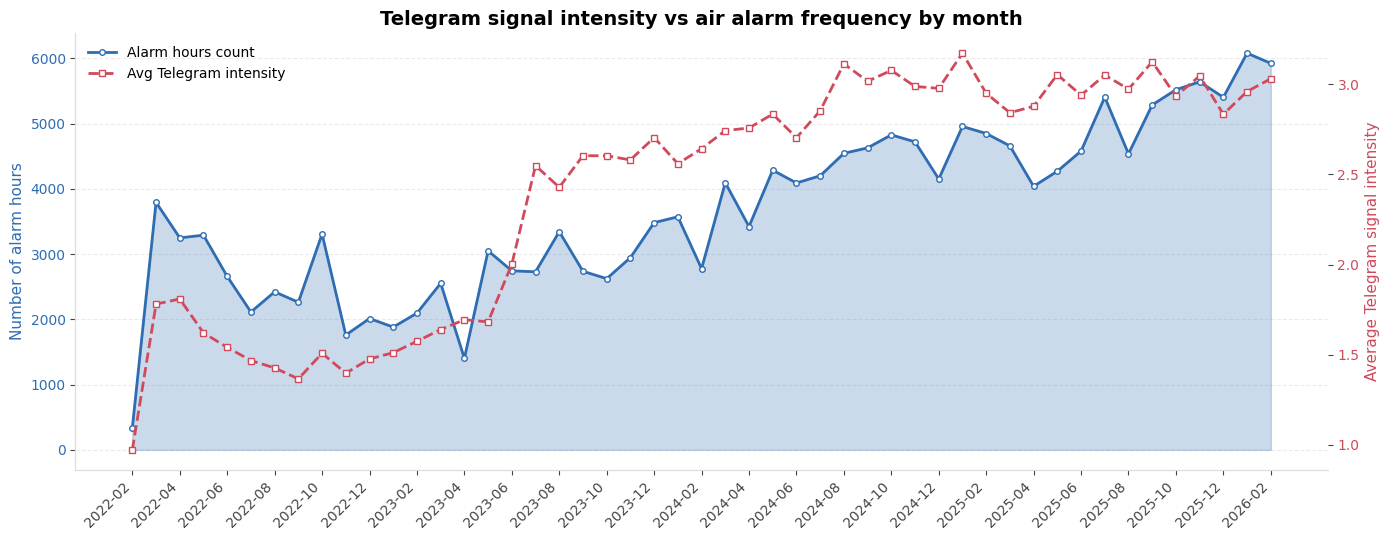

In [77]:
df['year_month'] = df['datetime_hour'].dt.to_period('M')

monthly = df.groupby('year_month').agg(alarm_count=('alarm_active', 'sum'), tg_intensity=('tg_total_intensity', 'mean')).reset_index()
monthly = monthly.iloc[:-1]

x = np.arange(len(monthly))
x_labels = monthly['year_month'].astype(str).tolist()

fig, ax1 = plt.subplots(figsize=(14, 5.5))

ax1.fill_between(x, monthly['alarm_count'], color=BLUE_MAIN, alpha=0.25)
ax1.plot(x, monthly['alarm_count'], color=BLUE_MAIN, linewidth=2, marker='o', markersize=4, markerfacecolor='white', label='Alarm hours count')
ax1.set_ylabel('Number of alarm hours', color=BLUE_MAIN)
ax1.tick_params(axis='y', labelcolor=BLUE_MAIN)

ax2 = ax1.twinx()
ax2.plot(x, monthly['tg_intensity'], color=RED_ACCENT, linewidth=2, linestyle='--', marker='s', markersize=4, markerfacecolor='white', label='Avg Telegram intensity')
ax2.set_ylabel('Average Telegram signal intensity', color=RED_ACCENT)
ax2.tick_params(axis='y', labelcolor=RED_ACCENT)

tick_idx = np.arange(0, len(x_labels), 2)
ax1.set_xticks(tick_idx)
ax1.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha='right')

ax1.set_title('Telegram signal intensity vs air alarm frequency by month')
ax1.grid(axis='y')
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

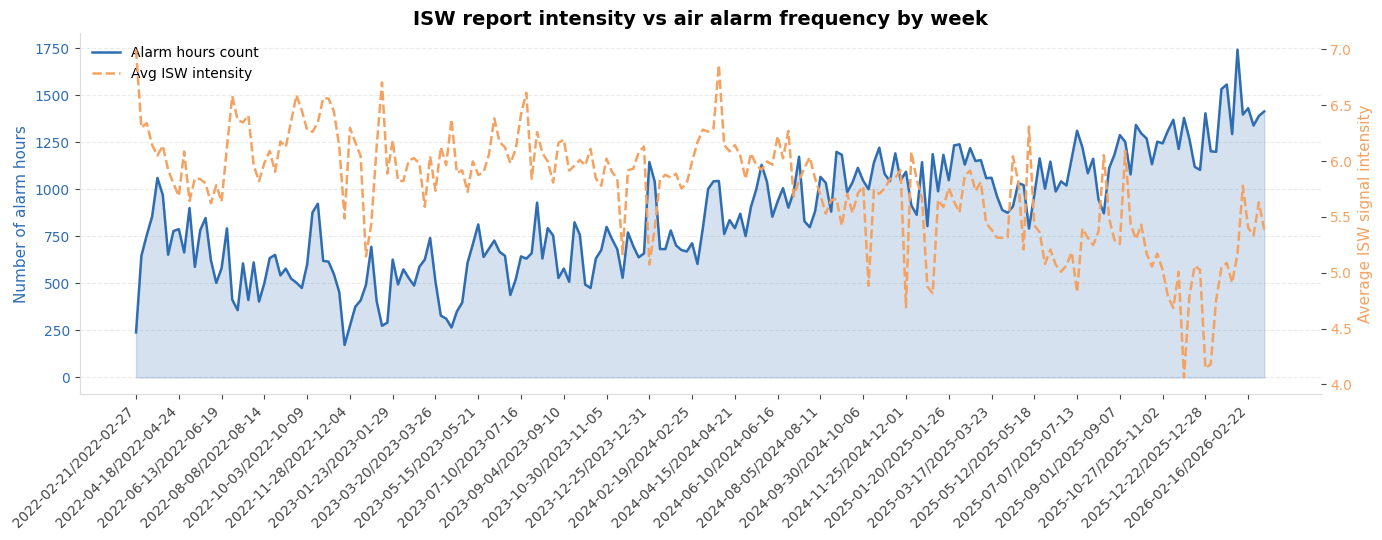

In [78]:
df['year_week'] = df['datetime_hour'].dt.to_period('W')

weekly = df.groupby('year_week').agg(alarm_count=('alarm_active', 'sum'), isw_intensity=('isw_total_intensity', 'mean')).reset_index()

weekly = weekly.iloc[:-1]
x = np.arange(len(weekly))
x_labels = weekly['year_week'].astype(str).tolist()

fig, ax1 = plt.subplots(figsize=(14, 5.5))

ax1.fill_between(x, weekly['alarm_count'], color=BLUE_MAIN, alpha=0.2)
ax1.plot(x, weekly['alarm_count'], color=BLUE_MAIN, linewidth=1.8, label='Alarm hours count')
ax1.set_ylabel('Number of alarm hours', color=BLUE_MAIN)
ax1.tick_params(axis='y', labelcolor=BLUE_MAIN)

ax2 = ax1.twinx()
ax2.plot(x, weekly['isw_intensity'], color=GOLD, linewidth=1.8, linestyle='--', label='Avg ISW intensity')
ax2.set_ylabel('Average ISW signal intensity', color=GOLD)
ax2.tick_params(axis='y', labelcolor=GOLD)

tick_idx = np.arange(0, len(x_labels), 8)
ax1.set_xticks(tick_idx)
ax1.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha='right')

ax1.set_title('ISW report intensity vs air alarm frequency by week')
ax1.grid(axis='y')
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

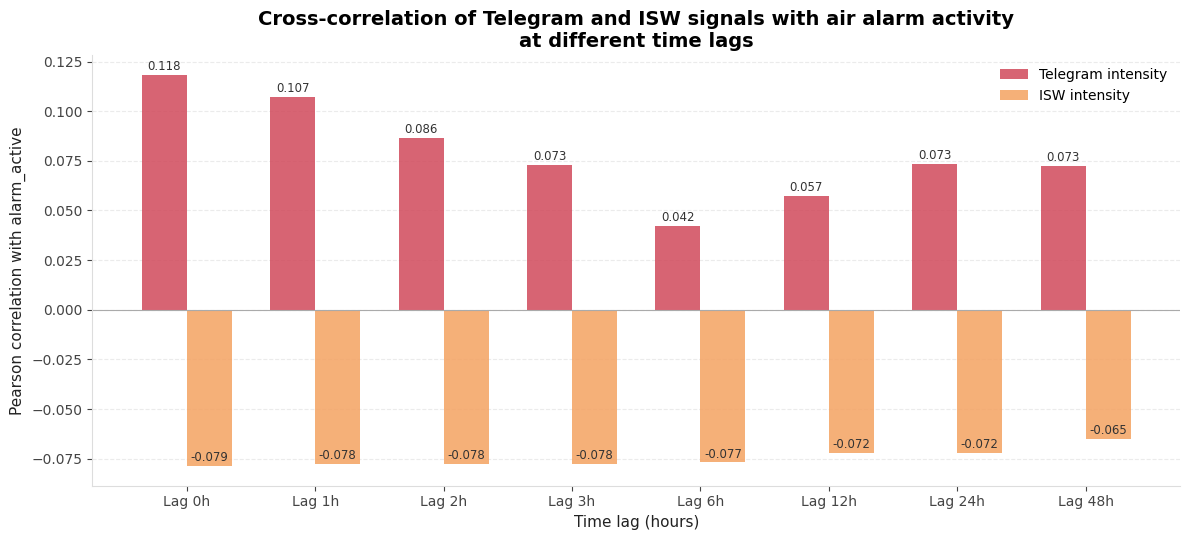

In [79]:
lags = [0, 1, 2, 3, 6, 12, 24, 48]

tg_corrs = []
isw_corrs = []

for lag in lags:
    tg_corrs.append(df['alarm_active'].corr(df['tg_total_intensity'].shift(lag)))
    isw_corrs.append(df['alarm_active'].corr(df['isw_total_intensity'].shift(lag)))

x = np.arange(len(lags))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5.5))

bars1 = ax.bar(x - width/2, tg_corrs, width, label='Telegram intensity', color=RED_ACCENT, alpha=0.85)
bars2 = ax.bar(x + width/2, isw_corrs, width, label='ISW intensity', color=GOLD, alpha=0.85)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.001, f'{height:.3f}', ha='center', va='bottom', fontsize=8.5, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels([f'lag {l}h' for l in lags])
ax.axhline(0, color='#AAAAAA', linewidth=0.8)
ax.set_title('Cross-correlation of Telegram and ISW signals with air alarm activity\nat different time lags')
ax.set_xlabel('Time lag (hours)')
ax.set_ylabel('Pearson correlation with alarm_active')
ax.legend(frameon=False)
ax.grid(axis='y')
ax.set_axisbelow(True)
ax.set_xticklabels(['Lag 0h', 'Lag 1h', 'Lag 2h', 'Lag 3h', 'Lag 6h', 'Lag 12h', 'Lag 24h', 'Lag 48h'])

plt.tight_layout()
plt.show()

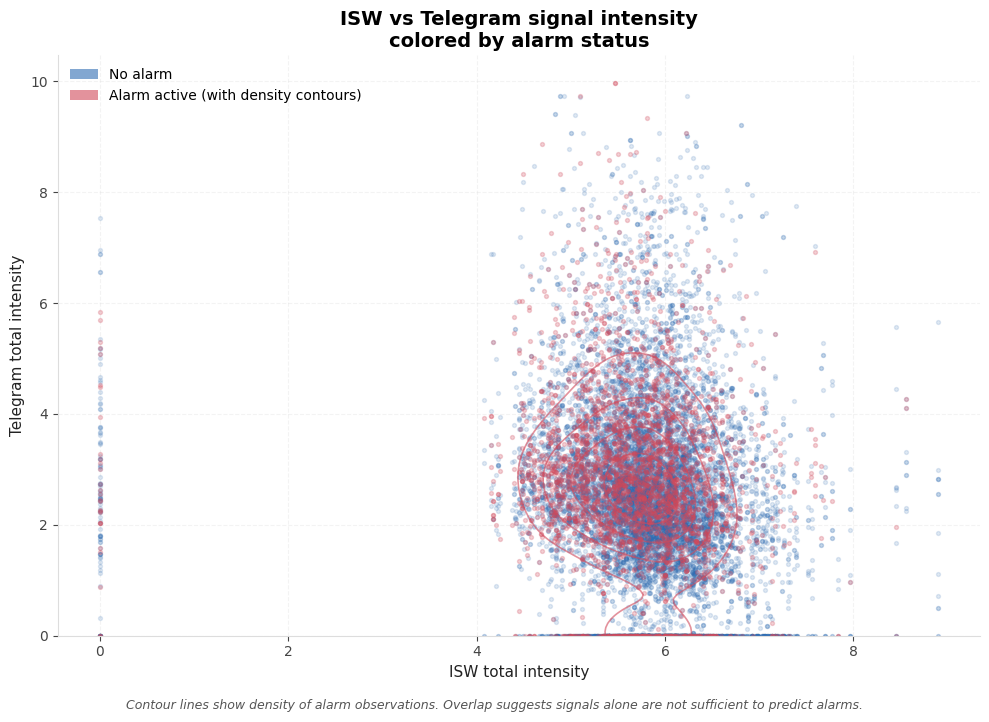

In [80]:
sample = df.sample(n=15000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))

no_alarm = sample[sample['alarm_active'] == 0]
alarm = sample[sample['alarm_active'] == 1]

ax.scatter(no_alarm['isw_total_intensity'], no_alarm['tg_total_intensity'], c=BLUE_MAIN, alpha=0.15, s=8, label='No alarm')
ax.scatter(alarm['isw_total_intensity'], alarm['tg_total_intensity'], c=RED_ACCENT, alpha=0.25, s=8, label='Alarm active')

from scipy.stats import gaussian_kde

xy = np.vstack([alarm['isw_total_intensity'], alarm['tg_total_intensity']])
kde = gaussian_kde(xy, bw_method=0.3)
xmin, xmax = alarm['isw_total_intensity'].quantile([0.01, 0.99])
ymin, ymax = alarm['tg_total_intensity'].quantile([0.01, 0.99])

xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
z = kde(positions).reshape(xx.shape)

ax.contour(xx, yy, z, levels=5, colors=RED_ACCENT, alpha=0.6, linewidths=1.2)

ax.set_title('ISW vs Telegram signal intensity\ncolored by alarm status')
ax.set_xlabel('ISW total intensity')
ax.set_ylabel('Telegram total intensity')

legend_elements = [
    mpatches.Patch(facecolor=BLUE_MAIN, alpha=0.6, label='No alarm'),
    mpatches.Patch(facecolor=RED_ACCENT, alpha=0.6, label='Alarm active (with density contours)')
]
ax.legend(handles=legend_elements, frameon=False)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

fig.text(0.5, -0.02,
         'Contour lines show density of alarm observations. Overlap suggests signals alone are not sufficient to predict alarms.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')

plt.tight_layout()
plt.show()

### Weather correlations analysis

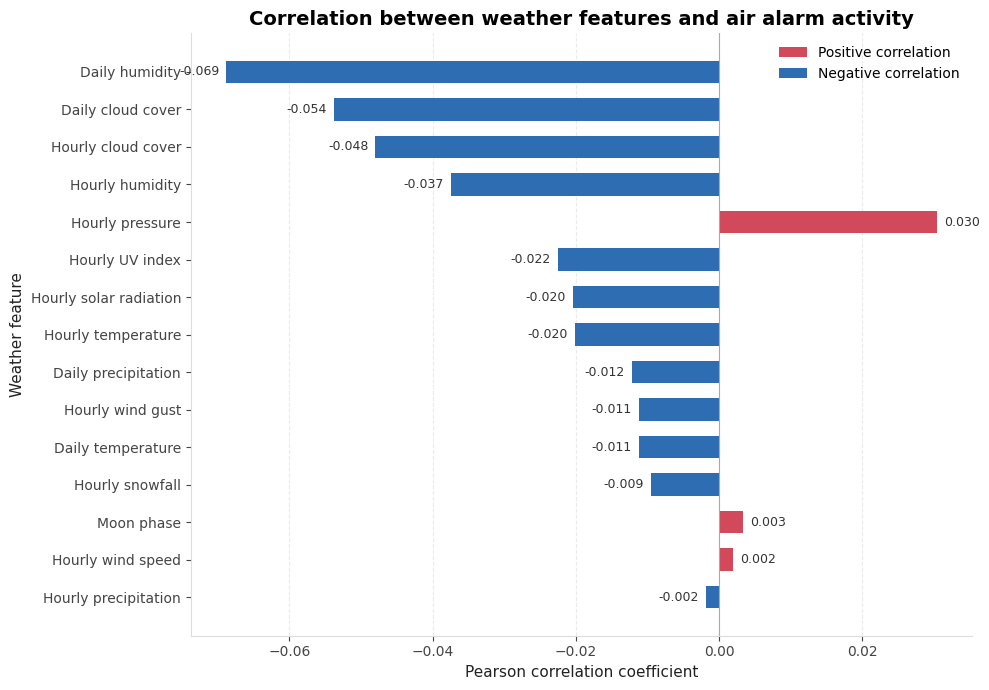

In [81]:
weather_cols = [c for c in ['hour_temp', 'hour_humidity', 'hour_precip', 'hour_windspeed', 'hour_windgust', 'hour_pressure', 'hour_cloudcover', 
                             'hour_solarradiation', 'hour_uvindex', 'hour_snow', 'day_temp', 'day_humidity', 'day_precip', 'day_cloudcover', 
                             'day_moonphase'] if c in df.columns]

label_map = {
    'hour_temp': 'Hourly temperature',
    'hour_humidity': 'Hourly humidity',
    'hour_precip': 'Hourly precipitation',
    'hour_windspeed': 'Hourly wind speed',
    'hour_windgust': 'Hourly wind gust',
    'hour_pressure': 'Hourly pressure',
    'hour_cloudcover': 'Hourly cloud cover',
    'hour_solarradiation': 'Hourly solar radiation',
    'hour_uvindex': 'Hourly UV index',
    'hour_snow': 'Hourly snowfall',
    'day_temp': 'Daily temperature',
    'day_humidity': 'Daily humidity',
    'day_precip': 'Daily precipitation',
    'day_cloudcover': 'Daily cloud cover',
    'day_moonphase': 'Moon phase'
}

corr = df[weather_cols + ['alarm_active']].corr()['alarm_active'].drop('alarm_active')
corr_sorted = corr.abs().sort_values(ascending=True)

corr_values = corr[corr_sorted.index].values
colors = [RED_ACCENT if v > 0 else BLUE_MAIN for v in corr_values]

readable_labels = [label_map.get(i, i) for i in corr_sorted.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(readable_labels, corr_values, color=colors, height=0.6)

ax.axvline(0, color='#AAAAAA', linewidth=0.8)

for bar, val in zip(bars, corr_values):
    ax.text(
        val + (0.001 if val >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
        color='#333333'
    )

ax.set_title('Correlation between weather features and air alarm activity')
ax.set_xlabel('Pearson correlation coefficient')
ax.set_ylabel('Weather feature')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED_ACCENT, label='Positive correlation'),
    Patch(facecolor=BLUE_MAIN, label='Negative correlation')
]
ax.legend(handles=legend_elements, frameon=False)
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

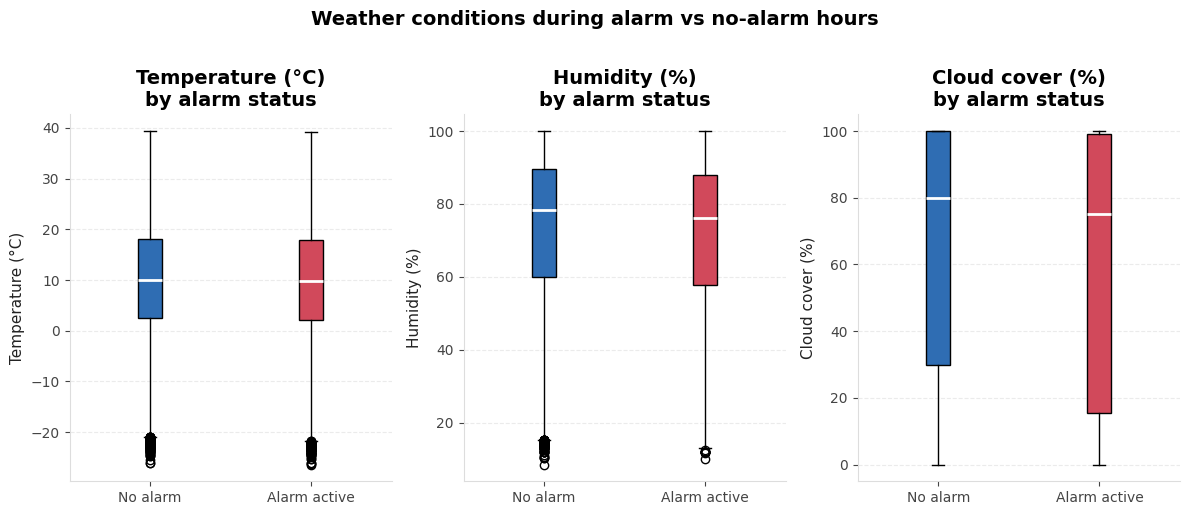

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, col, label in zip(axes,
    ['hour_temp', 'hour_humidity', 'hour_cloudcover'],
    ['Temperature (°C)', 'Humidity (%)', 'Cloud cover (%)']):

    data = [df[df['alarm_active']==0][col].dropna(),
            df[df['alarm_active']==1][col].dropna()]

    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))

    bp['boxes'][0].set_facecolor(BLUE_MAIN)
    bp['boxes'][1].set_facecolor(RED_ACCENT)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No alarm', 'Alarm active'])
    ax.set_title(f'{label}\nby alarm status')
    ax.set_ylabel(label)
    ax.grid(axis='y')
    ax.set_axisbelow(True)

plt.suptitle('Weather conditions during alarm vs no-alarm hours', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### General alarms activity analysis

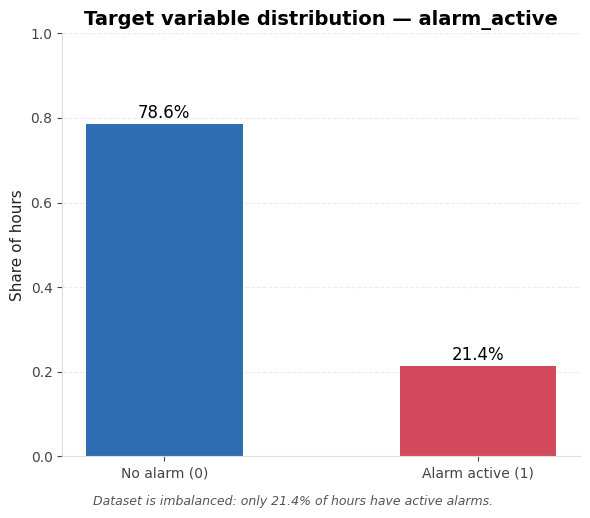

In [83]:
alarm_rate = df['alarm_active'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['No alarm (0)', 'Alarm active (1)'], [1 - alarm_rate, alarm_rate], color=[BLUE_MAIN, RED_ACCENT], width=0.5)

for bar, val in zip(bars, [1 - alarm_rate, alarm_rate]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.1%}', ha='center', va='bottom', fontsize=12)

ax.set_title('Target variable distribution — alarm_active')
ax.set_ylabel('Share of hours')
ax.set_ylim(0, 1)
ax.grid(axis='y')
ax.set_axisbelow(True)

fig.text(0.5, -0.02, f'Dataset is imbalanced: only {alarm_rate:.1%} of hours have active alarms. ', ha='center', fontsize=9, color=TEXT_GREY, style='italic')

plt.tight_layout()
plt.show()

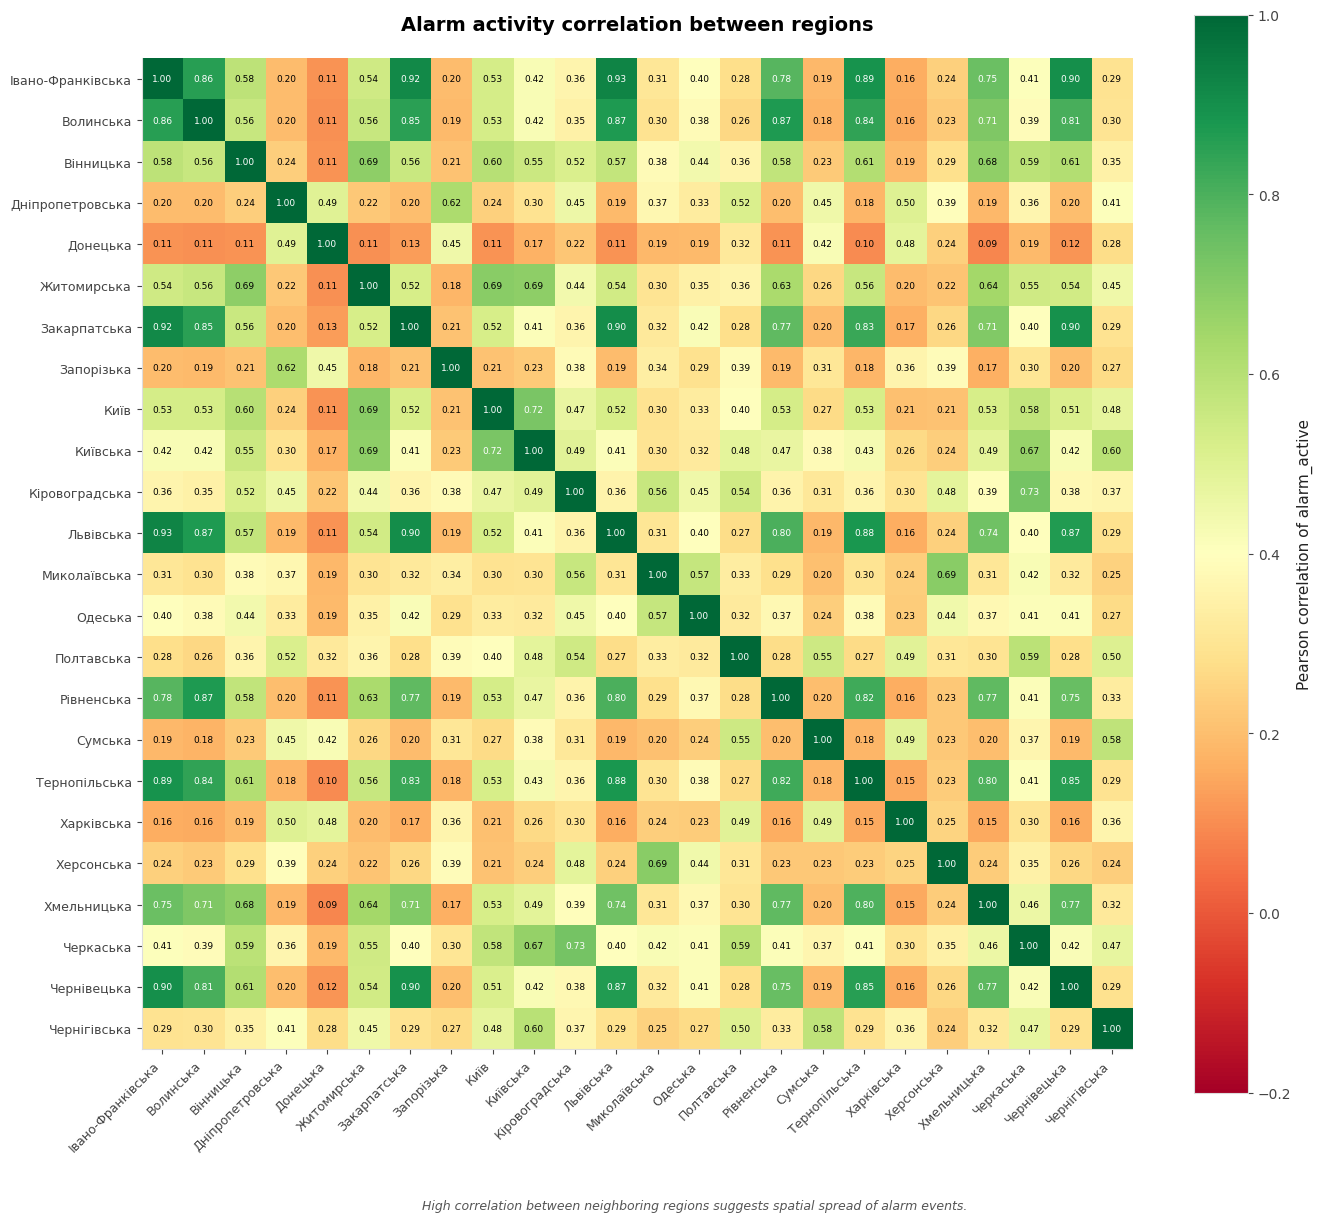

In [84]:
alarm_pivot = df.pivot_table(
    index='datetime_hour', 
    columns='region_key', 
    values='alarm_active'
)

region_corr = alarm_pivot.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(region_corr.values, cmap='RdYlGn', vmin=-0.2, vmax=1)

ax.set_xticks(range(len(region_corr.columns)))
ax.set_yticks(range(len(region_corr.columns)))
ax.set_xticklabels(region_corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(region_corr.columns, fontsize=9)

for i in range(len(region_corr)):
    for j in range(len(region_corr)):
        val = region_corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5,
                color='black' if val < 0.7 else 'white')

plt.colorbar(im, ax=ax, label='Pearson correlation of alarm_active')
ax.set_title('Alarm activity correlation between regions', pad=20)
fig.text(0.5, -0.02,
         'High correlation between neighboring regions suggests spatial spread of alarm events.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')
plt.tight_layout()
plt.show()

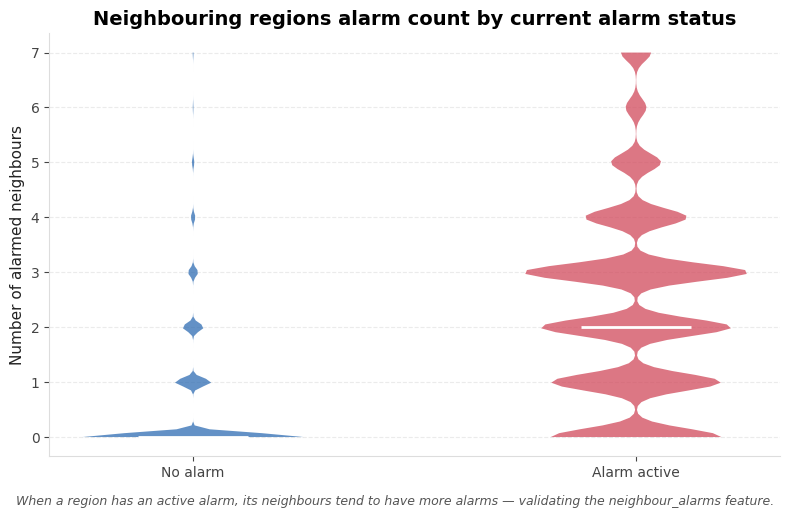

In [85]:
fig, ax = plt.subplots(figsize=(8, 5))

parts = ax.violinplot(
    [df[df['alarm_active']==0]['neighbour_alarms'],
     df[df['alarm_active']==1]['neighbour_alarms']],
    positions=[1, 2],
    showmedians=True,
    showextrema=False
)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([BLUE_MAIN, RED_ACCENT][i])
    pc.set_alpha(0.75)

parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

ax.set_xticks([1, 2])
ax.set_xticklabels(['No alarm', 'Alarm active'])
ax.set_title('Neighbouring regions alarm count by current alarm status')
ax.set_ylabel('Number of alarmed neighbours')
ax.grid(axis='y')
ax.set_axisbelow(True)

fig.text(0.5, -0.02,
         'When a region has an active alarm, its neighbours tend to have more alarms — validating the neighbour_alarms feature.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')

plt.tight_layout()
plt.show()

In [87]:
url = "https://raw.githubusercontent.com/EugeneBorshch/ukraine_geojson/master/UA_FULL_Ukraine.geojson"
geo = requests.get(url).json()

for i, feature in enumerate(geo['features']):
    feature['id'] = str(i)

df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])
df['year_month'] = df['datetime_hour'].dt.to_period('M').astype(str)

monthly = (df.groupby(['region_key', 'year_month'])['alarm_active'].mean().reset_index())

months = sorted(monthly['year_month'].unique())
timestamps = [str(int(pd.Timestamp(m).timestamp())) for m in months]

colormap = cm.LinearColormap(['#ffffcc', '#fd8d3c', '#800026'], vmin=0, vmax=1, caption='Average Alarm Rate')

styledict = {}

for i, feature in enumerate(geo['features']):
    iso = feature['properties'].get('iso3166-2', '')
    name_uk = feature['properties'].get('name:uk', '')
    
    region_name = name_uk.replace(' область', '').replace('Автономна Республіка ', '').strip()
    if region_name == "місто Київ": region_name = "Київ"
    if region_name == "місто Севастополь": region_name = "Севастополь"
    
    feature_id = feature['id']
    styledict[feature_id] = {}
    
    for month, ts in zip(months, timestamps):
        val = monthly[(monthly['region_key'] == region_name) & (monthly['year_month'] == month)]['alarm_active']
        rate = float(val.iloc[0]) if not val.empty else 0.0
        styledict[feature_id][ts] = {'color': colormap(rate),'opacity': 0.7}

m = folium.Map(location=[48.3, 31.1], zoom_start=6, tiles='CartoDB positron')

TimeSliderChoropleth(data=geo, styledict=styledict, ).add_to(m)

colormap.add_to(m)

title = '''
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: white; padding: 8px 18px;
     border-radius: 8px; box-shadow: 0 2px 6px rgba(0,0,0,0.15);
     font-family: Arial, sans-serif; font-size: 15px; 
     font-weight: bold; color: #222222; white-space: nowrap;">
     Average hourly alarm rate by region (2022–2026)
</div>
'''
m.get_root().html.add_child(folium.Element(title))

subtitle = '''
<div style="position: fixed; bottom: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: rgba(255,255,255,0.85); padding: 4px 14px;
     border-radius: 6px; font-family: Arial, sans-serif; 
     font-size: 11px; color: #555555; white-space: nowrap;">
     Share of hours with active alarm per month. Use slider to navigate through time.
</div>
'''
m.get_root().html.add_child(folium.Element(subtitle))
m

C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\4241769423.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Lag 1h', 'Lag 3h', 'Lag 6h', 'Lag 12h'])


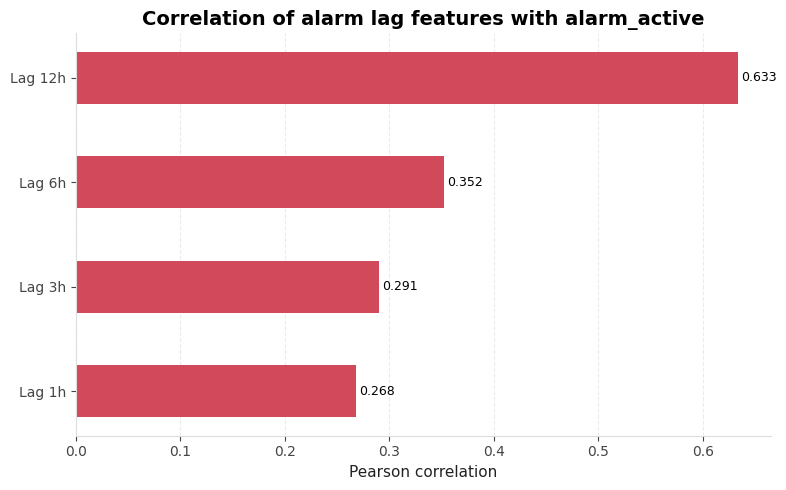

In [88]:
lag_cols = ['alarm_lag_1', 'alarm_lag_3', 'alarm_lag_6', 'alarm_lag_12']
corrs = df[lag_cols].corrwith(df['alarm_active']).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(corrs.index, corrs.values, color=RED_ACCENT, height=0.5)
for bar, val in zip(bars, corrs.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Correlation of alarm lag features with alarm_active')
ax.set_xlabel('Pearson correlation')
ax.set_yticklabels(['Lag 1h', 'Lag 3h', 'Lag 6h', 'Lag 12h'])
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

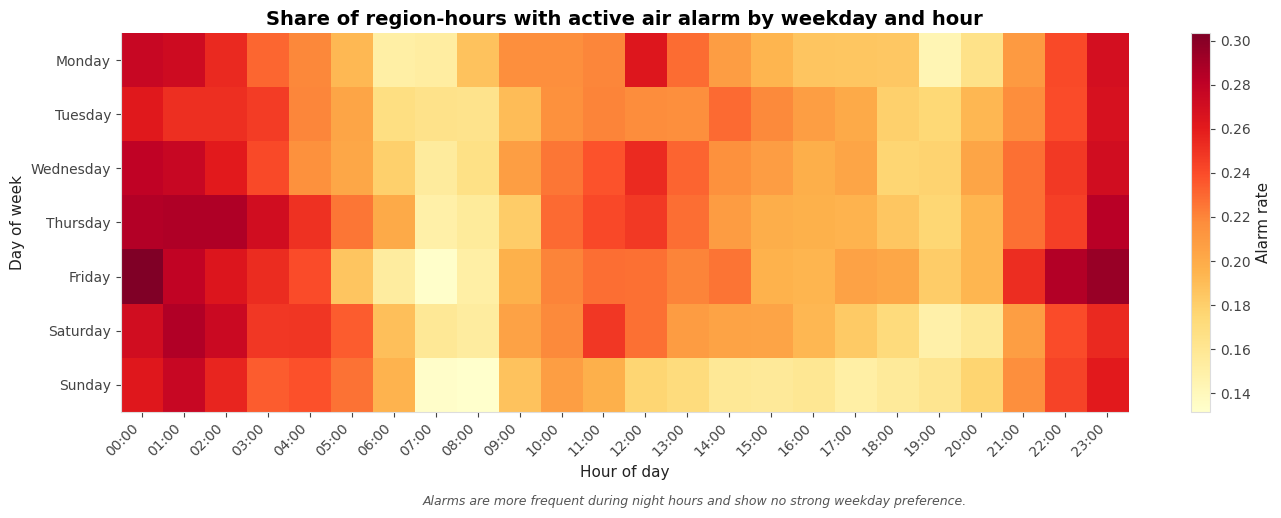

In [89]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (df.groupby(['day_of_week', 'hour'])['alarm_active'].mean().unstack())

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_yticks(range(7))
ax.set_yticklabels(days)

ax.set_title('Share of region-hours with active air alarm by weekday and hour')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Day of week')

fig.text(0.5, -0.02,
         'Alarms are more frequent during night hours and show no strong weekday preference.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')

plt.colorbar(im, ax=ax, label='Alarm rate')
plt.tight_layout()
plt.show()

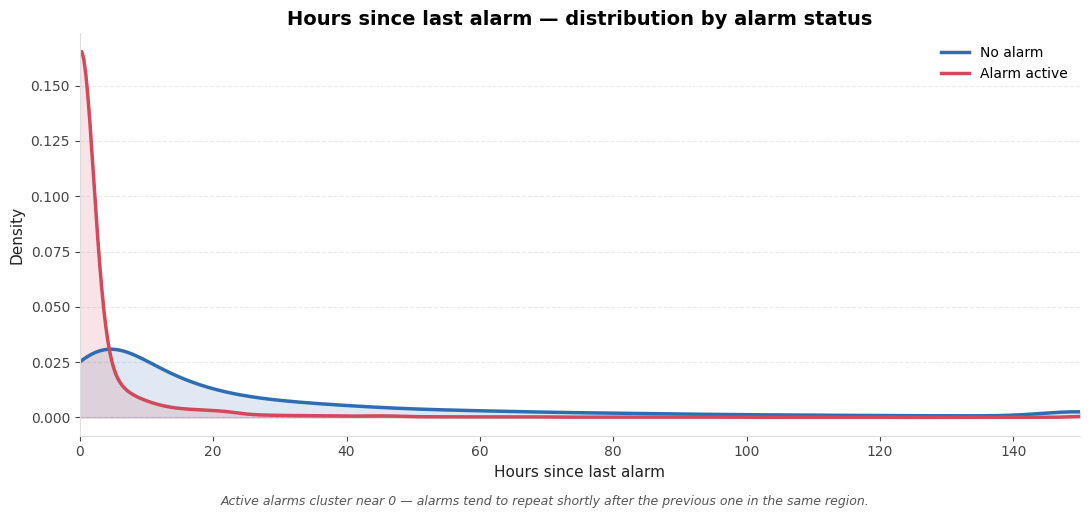

In [90]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(11, 5))

for status, color, label in [(0, BLUE_MAIN, 'No alarm'), (1, RED_ACCENT, 'Alarm active')]:
    data = df[df['alarm_active'] == status]['hours_since_last_alarm'].clip(upper=150)
    kde = gaussian_kde(data, bw_method=0.15)
    x_range = np.linspace(0, 150, 500)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=label)
    ax.fill_between(x_range, kde(x_range), alpha=0.15, color=color)

ax.set_title('Hours since last alarm — distribution by alarm status')
ax.set_xlabel('Hours since last alarm')
ax.set_ylabel('Density')
ax.set_xlim(0, 150)
ax.legend(frameon=False)
ax.grid(axis='y')
ax.set_axisbelow(True)

fig.text(0.5, -0.02,
         'Active alarms cluster near 0 — alarms tend to repeat shortly after the previous one in the same region.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')

plt.tight_layout()
plt.show()

## VI. Data shift for further models training

In [91]:
df_to_train = df_final.copy()
df_to_train = df_to_train.sort_values(['region_id', 'datetime_hour'])

In [92]:
isw_cols = [c for c in df_to_train.columns if 'isw_' in c]
df_to_train[isw_cols] = df_to_train.groupby('region_id')[isw_cols].shift(24).fillna(0)

In [93]:
df_to_train.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [94]:
tg_cols = [c for c in df_to_train.columns if 'tg_' in c]
df_to_train[tg_cols] = df_to_train.groupby('region_id')[tg_cols].shift(1).fillna(0)

In [95]:
df_to_train.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,Vinnytsia,2022-02-24 00:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Vinnytsia,2022-02-24 01:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,Vinnytsia,2022-02-24 02:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,Vinnytsia,2022-02-24 03:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,Vinnytsia,2022-02-24 04:00:00,5.0,0.7,2.8,-0.3,80.5,0.3,4.17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [96]:
hour_weather_cols = [c for c in df_to_train.columns if c.startswith('hour_')]
for col in hour_weather_cols:
    if df_to_train[col].dtype == bool:
        df_to_train[col] = df_to_train.groupby('region_id')[col].shift(1).fillna(False)
    else:
        df_to_train[col] = df_to_train.groupby('region_id')[col].shift(1).fillna(0)

C:\Users\vikam\AppData\Local\Temp\ipykernel_6736\2691752085.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_to_train[col] = df_to_train.groupby('region_id')[col].shift(1).fillna(False)


In [97]:
day_weather_cols = [c for c in df_to_train.columns if (c.startswith('day_') and c not in ['day_datetime', 'day_sunrise', 'day_sunset', 'day_moonphase', 'day_of_week'])]
df_to_train[day_weather_cols] = df_to_train.groupby('region_id')[day_weather_cols].shift(24).fillna(0)

In [98]:
df_to_train.isna().sum()

city_name              0
datetime_hour          0
day_tempmax            0
day_tempmin            0
day_temp               0
                      ..
tg_topic_max           0
tg_topic_entropy       0
tg_velocity_3h         0
tg_intensity_ema_6h    0
tg_intensity_zscore    0
Length: 468, dtype: int64

In [99]:
df_to_train['alarm_minutes_in_hour'] = (df_to_train.groupby('region_id')['alarm_minutes_in_hour'].shift(1).fillna(0))

In [100]:
df_to_train.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,Vinnytsia,2022-02-24 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Vinnytsia,2022-02-24 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,Vinnytsia,2022-02-24 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,Vinnytsia,2022-02-24 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,Vinnytsia,2022-02-24 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [101]:
print(f"Final dataset shape: {df_to_train.shape}")
print(f"Date range: {df_to_train['datetime_hour'].min()} → {df_to_train['datetime_hour'].max()}")
print(f"Regions: {df_to_train['region_id'].nunique()}")
print(f"Target balance: {df_to_train['alarm_active'].mean():.2%} positive")
print(f"NaN count: {df_to_train.isna().sum().sum()}")

Final dataset shape: (853536, 468)
Date range: 2022-02-24 00:00:00 → 2026-03-16 23:00:00
Regions: 24
Target balance: 21.38% positive
NaN count: 0


In [102]:
df_to_train.head(30)

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,Vinnytsia,2022-02-24 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Vinnytsia,2022-02-24 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
2,Vinnytsia,2022-02-24 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
3,Vinnytsia,2022-02-24 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
4,Vinnytsia,2022-02-24 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
5,Vinnytsia,2022-02-24 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
6,Vinnytsia,2022-02-24 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,2.913352,0.016725,0.089331,4.804361,2.913352,0.959866,2.041241
7,Vinnytsia,2022-02-24 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.563644,0.003134,0.019778,4.886176,0.563644,0.834795,0.061622
8,Vinnytsia,2022-02-24 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,0.634103,0.003863,0.024673,4.723152,0.634103,0.773287,0.119410
9,Vinnytsia,2022-02-24 09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.000000,0.0,0.000000,1.377721,0.005007,0.029923,5.155136,-1.535630,0.954766,0.779734


In [103]:
df_to_train.to_parquet(output, index=False, engine="pyarrow")